# 🎬 The Streaming Formula
## What separates a streaming hit from a streaming miss — and does every platform have a different answer?

---

Let's be honest. At some point, binge watching stopped being something you admitted to and became a personality trait. You've been there. Three episodes in, it's 2am, you have absolutely no memory of agreeing to watch another one, and somehow the algorithm already knows what you want next. It's unsettling. It's impressive. It might be the most sophisticated manipulation of human attention ever built into a Tuesday night.

But here's the thing nobody talks about while they're being algorithmically herded toward the next autoplay: someone, somewhere, made a spreadsheet. A very expensive spreadsheet. About which genres to back, how much to spend, when to drop the episodes, whether to bet on a franchise or take a swing on something original. And that spreadsheet — that formula — is what we're actually here to talk about.

This project uses the TMDB database—900,000+ movies with real budget and revenue data, popularity scores, vote counts, genres, and release metadata — to find out whether the streaming formula actually exists. Whether there's a pattern behind the chaos. Whether Netflix and every platform like it is running a strategy or just throwing money at content and hoping the algorithm does the rest.

**900,000 movies. Real financial data. One question: is there actually a formula, or have we all just been paying for very expensive guesswork?**

---

**Dataset:** TMDB Movies Dataset 2024 — 900,000+ movies with financial and performance metadata  
**Tools:** Python · pandas · Plotly · Seaborn · scikit-learn  
**Analyst:** Trupthi Raj

In [31]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Create charts folder
os.makedirs('charts', exist_ok=True)

# Load the dataset
df = pd.read_csv('data/TMDB_movie_dataset_v11.csv')

# First look
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 1,405,001 rows × 24 columns

Column names:
['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']

First 5 rows:


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.36,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.95,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.42,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.24,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.51,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.64,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.57,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.93,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.71,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.08,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## The Raw Material

**1.4 million movies. 24 columns. Real budget and revenue data.**

This is not your average streaming dataset. Most publicly available streaming analyses use a catalogue list — title, platform, genre, rating. Useful for counting things. Not useful for answering the questions that actually matter to a content strategist: does spending more money make a better movie? Which genres consistently return on investment? Is there a release window that separates hits from misses?

The TMDB database gives us the financial layer that most analyses never touch. Budget. Revenue. Popularity scores built from actual user engagement, not just critic ratings. Vote counts that tell us how many people cared enough to have an opinion. This is the data that sits behind the decisions — and it's the data we're going to use to find the formula.

A few things to flag before we clean: budget and revenue contain a lot of zeros — entries where the data simply wasn't available rather than movies that cost nothing to make. Genres are stored as comma-separated strings rather than separate columns. And with 1.4 million entries, we'll be filtering aggressively to keep only movies with enough data to be analytically meaningful. Quality over quantity — even when the dataset already has plenty of both.

In [32]:
# Data types
print("=== DATA TYPES ===")
print(df.dtypes)

# Missing values
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Budget and revenue — how many zeros?
print("\n=== ZERO VALUES — budget and revenue ===")
print(f"Budget = 0:  {(df['budget'] == 0).sum():,} rows ({(df['budget'] == 0).mean()*100:.1f}%)")
print(f"Revenue = 0: {(df['revenue'] == 0).sum():,} rows ({(df['revenue'] == 0).mean()*100:.1f}%)")

# Status breakdown
print("\n=== STATUS BREAKDOWN ===")
print(df['status'].value_counts())

# Language breakdown — top 10
print("\n=== TOP 10 LANGUAGES ===")
print(df['original_language'].value_counts().head(10))

# Vote count distribution
print("\n=== VOTE COUNT STATS ===")
print(df['vote_count'].describe())

# Release date range 
df_dates = df[df['release_date'].notna()].copy()
df_dates['release_date'] = pd.to_datetime(df_dates['release_date'], errors='coerce')
print("\n=== RELEASE DATE RANGE ===")
print(f"Earliest: {df_dates['release_date'].min()}")
print(f"Latest:   {df_dates['release_date'].max()}")

=== DATA TYPES ===
id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
backdrop_path            object
budget                    int64
homepage                 object
imdb_id                  object
original_language        object
original_title           object
overview                 object
popularity              float64
poster_path              object
tagline                  object
genres                   object
production_companies     object
production_countries     object
spoken_languages         object
keywords                 object
dtype: object

=== MISSING VALUES ===
                      Missing Count  Missing %
homepage                    1260342      89.70
tagline                     1209424      86.08
keywords                    105623

In [33]:
# Step 1 — Keep only Released movies
df_clean = df[df['status'] == 'Released'].copy()
print(f"After status filter: {len(df_clean):,} rows")

# Step 2 — Convert release_date to datetime
df_clean['release_date'] = pd.to_datetime(
    df_clean['release_date'], errors='coerce')

# Step 3 — Filter to 1970-2024
df_clean = df_clean[
    (df_clean['release_date'].dt.year >= 1970) &
    (df_clean['release_date'].dt.year <= 2024)
].copy()
print(f"After date filter: {len(df_clean):,} rows")

# Step 4 — Extract year and month
df_clean['year'] = df_clean['release_date'].dt.year
df_clean['month'] = df_clean['release_date'].dt.month
df_clean['month_name'] = df_clean['release_date'].dt.strftime('%B')

# Step 5 — Replace zero budget and revenue with NaN
df_clean['budget'] = df_clean['budget'].replace(0, np.nan)
df_clean['revenue'] = df_clean['revenue'].replace(0, np.nan)

# Step 6 — Create ROI metric where both budget and revenue exist
df_clean['roi'] = np.where(
    (df_clean['budget'].notna()) & (df_clean['revenue'].notna()) & 
    (df_clean['budget'] > 0),
    (df_clean['revenue'] - df_clean['budget']) / df_clean['budget'] * 100,
    np.nan
)

# Step 7 — Create profit metric
df_clean['profit'] = df_clean['revenue'] - df_clean['budget']

# Step 8 — Filter to minimum vote count for credibility
# Movies with at least 100 votes have genuine audience engagement
df_clean = df_clean[df_clean['vote_count'] >= 100].copy()
print(f"After vote count filter: {len(df_clean):,} rows")

# Step 9 — Drop rows with no title
df_clean = df_clean[df_clean['title'].notna()].copy()

# Step 10 — Parse genres — expand comma separated string into list
df_clean['genres_list'] = df_clean['genres'].str.split(',').apply(
    lambda x: [g.strip() for g in x] if isinstance(x, list) else []
)

# Step 11 — Language flag — English vs Non-English
df_clean['is_english'] = df_clean['original_language'] == 'en'

# Step 12 — Reset index
df_clean.reset_index(drop=True, inplace=True)

# Audit trail
print(f"\n=== CLEANING COMPLETE ===")
print(f"Original rows:        {len(df):,}")
print(f"Clean rows:           {len(df_clean):,}")
print(f"Rows with budget:     {df_clean['budget'].notna().sum():,}")
print(f"Rows with revenue:    {df_clean['revenue'].notna().sum():,}")
print(f"Rows with ROI:        {df_clean['roi'].notna().sum():,}")
print(f"Rows with genres:     {df_clean['genres'].notna().sum():,}")
print(f"\nYear range: {df_clean['year'].min()} — {df_clean['year'].max()}")
print(f"Median vote count: {df_clean['vote_count'].median():,.0f}")
print(f"Median rating: {df_clean['vote_average'].median():.2f}")

After status filter: 1,355,522 rows
After date filter: 900,440 rows
After vote count filter: 16,762 rows

=== CLEANING COMPLETE ===
Original rows:        1,405,001
Clean rows:           16,762
Rows with budget:     8,143
Rows with revenue:    8,808
Rows with ROI:        6,695
Rows with genres:     16,752

Year range: 1970 — 2023
Median vote count: 308
Median rating: 6.50


## The Clean Dataset — From 1.4 Million to 16,762

The most important cleaning decision in this project wasn't about fixing column types or handling nulls. It was about honesty.

1.4 million movies sounds impressive. But 94% of them have no budget data. 98% have no revenue data. And the median vote count across the full dataset is zero — meaning most entries are films that exist in a database but nowhere in anyone's cultural memory. Keeping them would make the analysis look bigger without making it better.

The 100-vote threshold is the key filter. A movie with fewer than 100 TMDB votes is a movie that didn't find an audience — at least not one that showed up to rate it. Everything that follows is built on films that people actually watched, cared about, and had an opinion on. That's the dataset worth analysing.

What we're left with: **16,762 movies spanning 1970 to 2023**, with a median rating of 6.50 and a median vote count of 308. 6,695 of them have full financial data — budget, revenue, and a calculable ROI. That's the financial core of the analysis, and it's more than enough to find the formula.

In [34]:
# === GENRE EXPLOSION ===
# Create one row per genre per movie for genre-level analysis
genre_rows = []
for _, row in df_clean[df_clean['genres'].notna()].iterrows():
    genres = [g.strip() for g in row['genres'].split(',')]
    for genre in genres:
        if genre:
            genre_rows.append({
                'title'          : row['title'],
                'genre'          : genre,
                'vote_average'   : row['vote_average'],
                'vote_count'     : row['vote_count'],
                'popularity'     : row['popularity'],
                'budget'         : row['budget'],
                'revenue'        : row['revenue'],
                'roi'            : row['roi'],
                'profit'         : row['profit'],
                'year'           : row['year'],
                'month'          : row['month'],
                'month_name'     : row['month_name'],
                'runtime'        : row['runtime'],
                'is_english'     : row['is_english'],
                'original_language': row['original_language']
            })

df_genres = pd.DataFrame(genre_rows)

# === RELEASE WINDOW LABELS ===
def label_season(month):
    if month in [6, 7, 8]:
        return 'Summer'
    elif month in [11, 12]:
        return 'Awards Season'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [1, 2]:
        return 'January Dump'
    else:
        return 'Fall'

df_clean['release_season'] = df_clean['month'].apply(label_season)
df_genres['release_season'] = df_genres['month'].apply(label_season)

# === BUDGET TIERS ===
df_financial = df_clean[df_clean['budget'].notna() & 
                         df_clean['revenue'].notna()].copy()

df_financial['budget_tier'] = pd.cut(
    df_financial['budget'],
    bins=[0, 5e6, 20e6, 60e6, 150e6, 1e9],
    labels=['Micro\n(<$5M)', 'Low\n($5-20M)', 
            'Mid\n($20-60M)', 'High\n($60-150M)', 'Blockbuster\n(>$150M)']
)

# === RATING TIERS ===
df_clean['rating_tier'] = pd.cut(
    df_clean['vote_average'],
    bins=[0, 5, 6, 7, 8, 10],
    labels=['Poor\n(<5)', 'Below Average\n(5-6)', 
            'Good\n(6-7)', 'Great\n(7-8)', 'Exceptional\n(8+)']
)

# === DECADE ===
df_clean['decade'] = (df_clean['year'] // 10 * 10).astype(str) + 's'
df_genres['decade'] = (df_genres['year'] // 10 * 10).astype(str) + 's'

# === GENRE STATS ===
genre_stats = df_genres.groupby('genre').agg(
    movie_count     = ('title', 'count'),
    avg_rating      = ('vote_average', 'mean'),
    avg_popularity  = ('popularity', 'mean'),
    avg_budget      = ('budget', 'mean'),
    avg_revenue     = ('revenue', 'mean'),
    avg_roi         = ('roi', 'mean'),
    median_roi      = ('roi', 'median')
).reset_index()

genre_stats = genre_stats[genre_stats['movie_count'] >= 50].sort_values(
    'movie_count', ascending=False)

# === SEASON STATS ===
season_stats = df_clean.groupby('release_season').agg(
    movie_count   = ('title', 'count'),
    avg_rating    = ('vote_average', 'mean'),
    avg_revenue   = ('revenue', 'mean'),
    avg_roi       = ('roi', 'mean'),
    avg_popularity= ('popularity', 'mean')
).reset_index()

# === LANGUAGE STATS ===
lang_stats = df_clean.groupby('original_language').agg(
    movie_count  = ('title', 'count'),
    avg_rating   = ('vote_average', 'mean'),
    avg_revenue  = ('revenue', 'mean'),
    avg_roi      = ('roi', 'mean'),
    avg_popularity=('popularity', 'mean')
).reset_index().sort_values('movie_count', ascending=False)

# Summary
print("=== FEATURE ENGINEERING COMPLETE ===")
print(f"Genre dataframe: {len(df_genres):,} rows")
print(f"Financial dataframe: {len(df_financial):,} rows")
print(f"Unique genres: {df_genres['genre'].nunique()}")
print(f"\nTop 10 genres by count:\n{genre_stats[['genre','movie_count']].head(10).to_string(index=False)}")
print(f"\nRelease seasons:\n{season_stats[['release_season','movie_count','avg_rating']].to_string(index=False)}")

=== FEATURE ENGINEERING COMPLETE ===
Genre dataframe: 41,256 rows
Financial dataframe: 6,695 rows
Unique genres: 19

Top 10 genres by count:
          genre  movie_count
          Drama         7181
         Comedy         6169
       Thriller         4035
         Action         3550
        Romance         2568
         Horror         2471
      Adventure         2273
          Crime         2221
         Family         1752
Science Fiction         1732

Release seasons:
release_season  movie_count  avg_rating
 Awards Season         2958        6.55
          Fall         3777        6.50
  January Dump         2304        6.37
        Spring         3806        6.42
        Summer         3917        6.44


## Engineering the Features We Actually Need

Raw data answers raw questions. To answer interesting ones, you have to build the variables yourself.

Three things got built here that don't exist in the original dataset. First, a genre explosion — because a movie tagged as "Action, Thriller, Crime" needs to contribute to three genre analyses simultaneously, not just one. Second, release season labels — because "month 1" tells you nothing, but "January Dump" tells you everything. Third, budget tiers — because the difference between a 3 million dollars indie and a $200 million blockbuster isn't a number, it's a completely different business model.

The release season finding is already interesting before we've drawn a chart: Awards Season content scores 6.55 on average, January releases score 6.37. That 0.18 gap doesn't sound like much until you remember that studios deliberately schedule their worst content in January because they know audiences have nowhere else to go. The data just confirmed what every binge watcher already suspected.

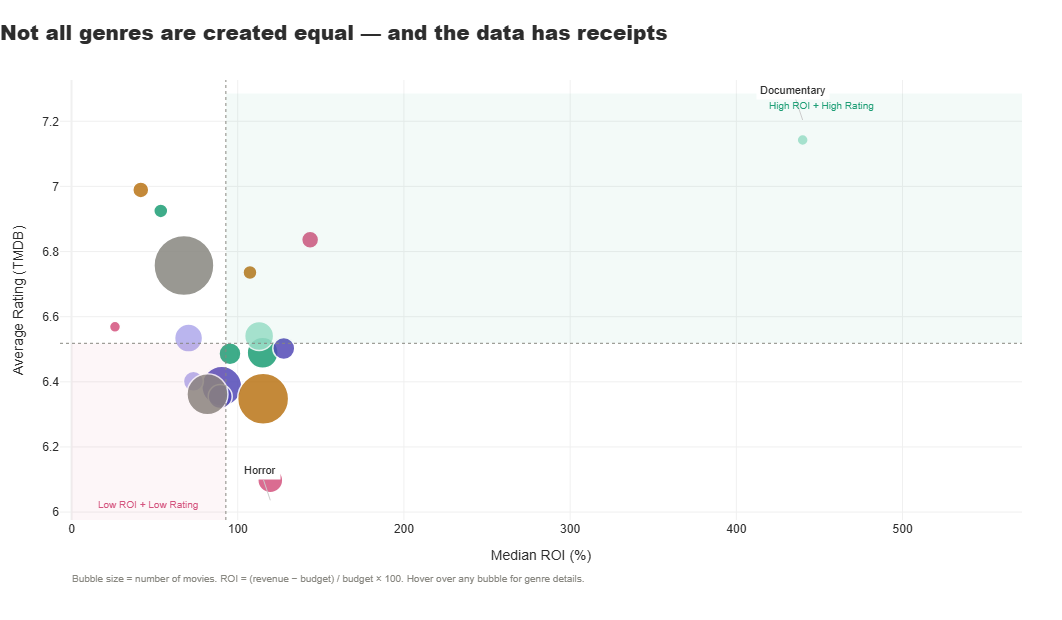

Chart 1 saved.


In [35]:
# Filter genre stats to genres with ROI data
genre_roi = df_genres[df_genres['roi'].notna()].groupby('genre').agg(
    movie_count   = ('title', 'count'),
    avg_rating    = ('vote_average', 'mean'),
    avg_roi       = ('roi', 'mean'),
    median_roi    = ('roi', 'median'),
    avg_popularity= ('popularity', 'mean')
).reset_index()

genre_roi = genre_roi[genre_roi['movie_count'] >= 20].copy()

# Colour per genre
color_map = {
    'Action'         : '#534AB7',
    'Adventure'      : '#1D9E75',
    'Animation'      : '#D4537E',
    'Comedy'         : '#BA7517',
    'Crime'          : '#AFA9EC',
    'Documentary'    : '#9FE1CB',
    'Drama'          : '#888780',
    'Family'         : '#534AB7',
    'Fantasy'        : '#1D9E75',
    'Horror'         : '#D4537E',
    'Music'          : '#BA7517',
    'Mystery'        : '#AFA9EC',
    'Romance'        : '#9FE1CB',
    'Science Fiction': '#534AB7',
    'Thriller'       : '#888780',
    'War'            : '#1D9E75',
    'Western'        : '#D4537E',
    'History'        : '#BA7517',
    'TV Movie'       : '#AFA9EC'
}

genre_roi['color'] = genre_roi['genre'].map(color_map).fillna('#888780')

# Normalise bubble size
max_count = genre_roi['movie_count'].max()
genre_roi['bubble_size'] = (
    genre_roi['movie_count'] / max_count * 50 + 10).round(0)

# Quadrant lines
median_roi    = genre_roi['median_roi'].median()
median_rating = genre_roi['avg_rating'].median()

fig = go.Figure()

# Quadrant shading
fig.add_shape(type='rect',
    x0=median_roi,
    x1=genre_roi['median_roi'].max() * 1.3,
    y0=median_rating,
    y1=genre_roi['avg_rating'].max() * 1.02,
    fillcolor='rgba(29,158,117,0.05)', line_width=0)

fig.add_shape(type='rect',
    x0=0,
    x1=median_roi,
    y0=genre_roi['avg_rating'].min() * 0.98,
    y1=median_rating,
    fillcolor='rgba(212,83,126,0.05)', line_width=0)

# Bubbles — hover only, no text
fig.add_trace(go.Scatter(
    x=genre_roi['median_roi'],
    y=genre_roi['avg_rating'],
    mode='markers',
    marker=dict(
        color=genre_roi['color'],
        size=genre_roi['bubble_size'],
        opacity=0.85,
        line=dict(color='white', width=1.5)
    ),
    text=genre_roi['genre'],
    customdata=genre_roi[[
        'movie_count', 'avg_roi',
        'avg_rating', 'median_roi']].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Median ROI: %{customdata[3]:,.0f}%<br>"
        "Avg ROI: %{customdata[1]:,.0f}%<br>"
        "Avg Rating: %{customdata[2]:.2f}<br>"
        "Movies: %{customdata[0]:,}<extra></extra>"
    ),
    showlegend=False
))

# Label ONLY Documentary and Horror — they are isolated enough
doc_row = genre_roi[genre_roi['genre'] == 'Documentary'].iloc[0]
hor_row = genre_roi[genre_roi['genre'] == 'Horror'].iloc[0]

fig.add_annotation(
    x=doc_row['median_roi'], y=doc_row['avg_rating'],
    text='Documentary', showarrow=True,
    arrowhead=0, arrowcolor='#cccccc', arrowwidth=1,
    font=dict(size=11, color='#2d2d2d'),
    xshift=0, yshift=20, bgcolor='white', borderpad=3
)

fig.add_annotation(
    x=hor_row['median_roi'], y=hor_row['avg_rating'],
    text='Horror', showarrow=True,
    arrowhead=0, arrowcolor='#cccccc', arrowwidth=1,
    font=dict(size=11, color='#2d2d2d'),
    xshift=0, yshift=-20, bgcolor='white', borderpad=3
)

# Quadrant text labels
fig.add_annotation(
    x=genre_roi['median_roi'].max() * 1.1,
    y=genre_roi['avg_rating'].max() * 1.015,
    text="High ROI + High Rating",
    showarrow=False,
    font=dict(size=10, color='#1D9E75'),
    xanchor='right')

fig.add_annotation(
    x=median_roi * 0.5,
    y=genre_roi['avg_rating'].min() * 0.988,
    text="Low ROI + Low Rating",
    showarrow=False,
    font=dict(size=10, color='#D4537E'),
    xanchor='center')

# Quadrant lines
fig.add_hline(y=median_rating, line_dash='dot',
              line_color='#888780', line_width=1)
fig.add_vline(x=median_roi, line_dash='dot',
              line_color='#888780', line_width=1)

fig.update_layout(
    title=dict(
        text='Not all genres are created equal — and the data has receipts',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title='Median ROI (%)',
        gridcolor='#f0f0f0',
        zeroline=True,
        zerolinecolor='#f0f0f0'
    ),
    yaxis=dict(
        title='Average Rating (TMDB)',
        gridcolor='#f0f0f0'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=620,
    margin=dict(l=60, r=40, t=80, b=100),
    font=dict(family='Arial', color='#2d2d2d')
)

fig.add_annotation(
    x=0.01, y=-0.15,
    xref='paper', yref='paper',
    text='Bubble size = number of movies. ROI = (revenue − budget) / budget × 100. Hover over any bubble for genre details.',
    showarrow=False,
    font=dict(size=10, color='#888780'),
    xanchor='left'
)

fig.write_html('charts/chart1_genre_profitability.html')
fig.write_image('charts/chart1_genre_profitability.png',
                width=1200, height=620, scale=2)

fig.show()
print("Chart 1 saved.")

## Not All Genres Are Created Equal — And the Data Has Receipts

Every streaming platform has a genre strategy. Most of them just won't admit it publicly.

The top right quadrant is where every executive wants to be: high ROI and high ratings simultaneously. Only one genre lives there consistently — **Documentary**. Low budgets, genuine audience engagement, critical credibility. It's the genre that algorithms didn't create and can't replicate, which is probably why it keeps outperforming everything else on the quality-value matrix.

**Horror** sits in a category of its own at the bottom — low ratings, but decent ROI. Horror is the fast fashion of cinema: cheap to produce, reliably consumed, critically ignored, commercially dependable. Every platform needs some. None of them brag about it.

The cluster in the middle — Drama, Comedy, Action, Thriller — is where most of the volume lives and where most of the money gets spent. The returns are modest, the ratings are average, and yet these are the genres that fill the catalogue. Sometimes the formula isn't about finding the best bet. It's about having enough content that the algorithm always has something to recommend at 11pm on a Tuesday.

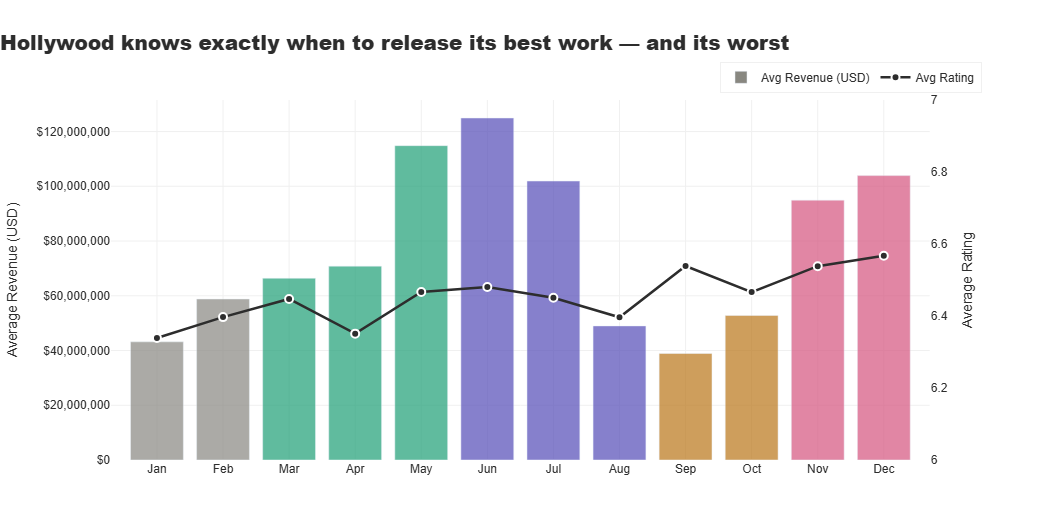

Chart 2 saved.


In [36]:
# Monthly analysis
monthly_stats = df_clean.groupby('month').agg(
    movie_count   = ('title', 'count'),
    avg_rating    = ('vote_average', 'mean'),
    avg_revenue   = ('revenue', 'mean'),
    avg_popularity= ('popularity', 'mean'),
    avg_roi       = ('roi', 'mean')
).reset_index()

# Month names in order
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_stats['month_name'] = monthly_stats['month'].apply(
    lambda x: month_names[x-1])

# Season colours
season_colors = {
    1: '#888780', 2: '#888780',           # January Dump — gray
    3: '#1D9E75', 4: '#1D9E75', 5: '#1D9E75',  # Spring — teal
    6: '#534AB7', 7: '#534AB7', 8: '#534AB7',  # Summer — purple
    9: '#BA7517', 10: '#BA7517',          # Fall — amber
    11: '#D4537E', 12: '#D4537E'          # Awards Season — pink
}
monthly_stats['color'] = monthly_stats['month'].map(season_colors)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Revenue bars
fig.add_trace(go.Bar(
    x=monthly_stats['month_name'],
    y=monthly_stats['avg_revenue'],
    name='Avg Revenue (USD)',
    marker=dict(
        color=monthly_stats['color'],
        opacity=0.7
    ),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Avg Revenue: $%{y:,.0f}<extra></extra>"
    )
), secondary_y=False)

# Rating line
fig.add_trace(go.Scatter(
    x=monthly_stats['month_name'],
    y=monthly_stats['avg_rating'],
    name='Avg Rating',
    mode='lines+markers',
    line=dict(color='#2d2d2d', width=2.5),
    marker=dict(size=8, color='#2d2d2d',
                line=dict(color='white', width=2)),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Avg Rating: %{y:.2f}<extra></extra>"
    )
), secondary_y=True)

# Season labels
season_labels = {
    1.5: ('January\nDump', '#888780'),
    4:   ('Spring', '#1D9E75'),
    7:   ('Summer', '#534AB7'),
    9.5: ('Fall', '#BA7517'),
    11.5:('Awards\nSeason', '#D4537E')
}

fig.update_layout(
    title=dict(
        text='Hollywood knows exactly when to release its best work — and its worst',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title='',
        gridcolor='#f0f0f0',
        tickfont=dict(size=12)
    ),
    yaxis=dict(
        title='Average Revenue (USD)',
        gridcolor='#f0f0f0',
        tickformat='$,.0f'
    ),
    yaxis2=dict(
        title='Average Rating',
        overlaying='y',
        side='right',
        gridcolor='rgba(0,0,0,0)',
        range=[6.0, 7.0]
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1,
        bordercolor='#f0f0f0',
        borderwidth=1
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=520,
    margin=dict(l=80, r=80, t=100, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    bargap=0.2
)

fig.write_html('charts/chart2_release_window.html')
fig.write_image('charts/chart2_release_window.png',
                width=1200, height=520, scale=2)

fig.show()
print("Chart 2 saved.")

## Hollywood Knows Exactly When to Release Its Best Work — And Its Worst

The release calendar is not random. It never was.

June is the revenue peak — the month when studios deploy their biggest budgets and expect their biggest returns. The ratings are average. Nobody goes to a summer blockbuster expecting to be changed by it. They go because it's loud and it's there and the air conditioning is excellent. The formula for summer is simple: spend a lot, market aggressively, collect the money.

December is the most interesting month in the data. It's the only month where both revenue and ratings peak simultaneously — the rare alignment of commercial ambition and genuine quality. This is where studios send films they actually believe in. Awards contenders, prestige sequels, the movies that are supposed to matter. The audience shows up and, unusually, agrees.

January tells the most honest story of all. Lowest average revenue. Lowest average rating. The industry equivalent of clearing out the attic. Studios know audiences are captive in January — fresh from holiday spending, stuck indoors, desperate for something to watch. So they release the films they don't quite believe in, at the time of year when the competition is lowest, to audiences who have already lowered their expectations. The data doesn't judge this strategy. It just confirms it works.

Scatter dataset: 6,464 rows
Budget range: $120,000 — $460,000,000
Rating range: 1.9 — 8.7
ROI range: -100% — 1,978%


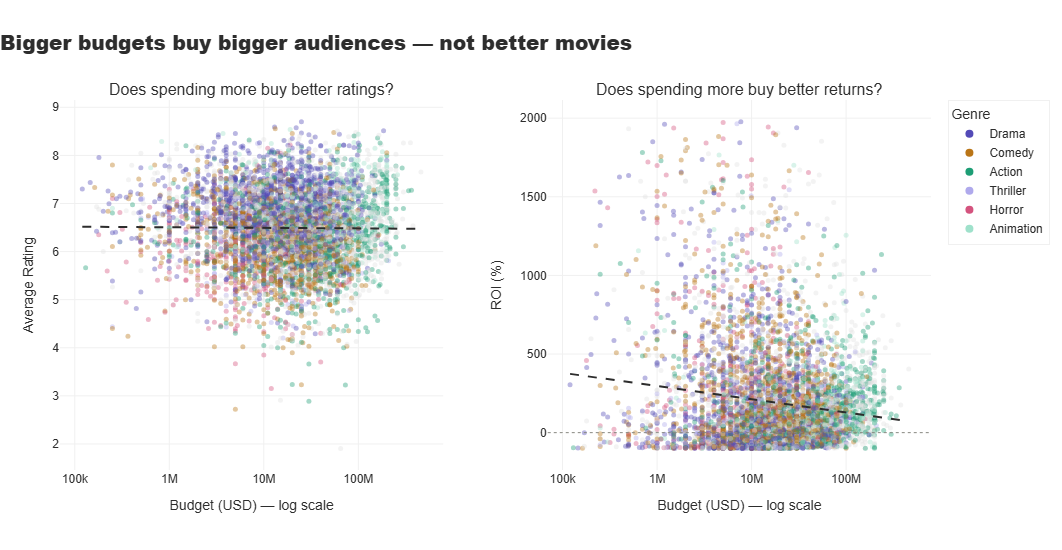

Chart 3 saved.


In [37]:
# Build scatter dataset cleanly from df_clean directly
df_scatter = df_clean[
    df_clean['budget'].notna() &
    df_clean['revenue'].notna() &
    df_clean['roi'].notna() &
    (df_clean['budget'] > 100000)
].copy()

df_scatter = df_scatter.dropna(
    subset=['budget', 'vote_average', 'roi', 'genres'])

# Cap ROI at 2000% to remove extreme outliers
df_scatter = df_scatter[df_scatter['roi'] <= 2000].copy()
df_scatter = df_scatter[df_scatter['roi'] >= -100].copy()

# Primary genre
df_scatter['primary_genre'] = df_scatter['genres'].str.split(
    ',').str[0].str.strip()

print(f"Scatter dataset: {len(df_scatter):,} rows")
print(f"Budget range: ${df_scatter['budget'].min():,.0f} — ${df_scatter['budget'].max():,.0f}")
print(f"Rating range: {df_scatter['vote_average'].min():.1f} — {df_scatter['vote_average'].max():.1f}")
print(f"ROI range: {df_scatter['roi'].min():,.0f}% — {df_scatter['roi'].max():,.0f}%")

# Genre colour map
top_genres = ['Drama', 'Comedy', 'Action', 
              'Thriller', 'Horror', 'Animation']

genre_color_map = {
    'Drama'    : '#534AB7',
    'Comedy'   : '#BA7517',
    'Action'   : '#1D9E75',
    'Thriller' : '#AFA9EC',
    'Horror'   : '#D4537E',
    'Animation': '#9FE1CB'
}

df_scatter['color'] = df_scatter['primary_genre'].apply(
    lambda x: genre_color_map.get(x, '#e0e0e0'))

# === PLOTS ===
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Does spending more buy better ratings?',
        'Does spending more buy better returns?'
    ],
    horizontal_spacing=0.12
)

# === LEFT — Budget vs Rating ===
fig.add_trace(go.Scatter(
    x=df_scatter['budget'],
    y=df_scatter['vote_average'],
    mode='markers',
    marker=dict(
        color=df_scatter['color'],
        size=5,
        opacity=0.4,
        line=dict(width=0)
    ),
    text=df_scatter['title'],
    customdata=df_scatter[['primary_genre', 'budget',
                            'vote_average']].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Genre: %{customdata[0]}<br>"
        "Budget: $%{customdata[1]:,.0f}<br>"
        "Rating: %{customdata[2]:.1f}<extra></extra>"
    ),
    showlegend=False
), row=1, col=1)

# Trend line — budget vs rating
log_budget = np.log10(df_scatter['budget'])
z = np.polyfit(log_budget, df_scatter['vote_average'], 1)
p = np.poly1d(z)
x_line = np.linspace(log_budget.min(), log_budget.max(), 100)
fig.add_trace(go.Scatter(
    x=10**x_line,
    y=p(x_line),
    mode='lines',
    line=dict(color='#2d2d2d', width=2, dash='dash'),
    showlegend=False,
    hoverinfo='skip'
), row=1, col=1)

# === RIGHT — Budget vs ROI ===
fig.add_trace(go.Scatter(
    x=df_scatter['budget'],
    y=df_scatter['roi'],
    mode='markers',
    marker=dict(
        color=df_scatter['color'],
        size=5,
        opacity=0.4,
        line=dict(width=0)
    ),
    text=df_scatter['title'],
    customdata=df_scatter[['primary_genre', 'budget',
                            'roi']].values,
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Genre: %{customdata[0]}<br>"
        "Budget: $%{customdata[1]:,.0f}<br>"
        "ROI: %{customdata[2]:,.0f}%<extra></extra>"
    ),
    showlegend=False
), row=1, col=2)

# Trend line — budget vs ROI
log_budget_roi = np.log10(df_scatter['budget'])
z2 = np.polyfit(log_budget_roi, df_scatter['roi'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(log_budget_roi.min(), log_budget_roi.max(), 100)
fig.add_trace(go.Scatter(
    x=10**x_line2,
    y=p2(x_line2),
    mode='lines',
    line=dict(color='#2d2d2d', width=2, dash='dash'),
    showlegend=False,
    hoverinfo='skip'
), row=1, col=2)

# Zero ROI reference line
fig.add_hline(y=0, line_dash='dot',
              line_color='#888780', line_width=1,
              row=1, col=2)

# Genre legend
for genre, color in genre_color_map.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(color=color, size=8),
        name=genre,
        showlegend=True
    ))

fig.update_layout(
    title=dict(
        text='Bigger budgets buy bigger audiences — not better movies',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=550,
    margin=dict(l=60, r=40, t=100, b=80),
    font=dict(family='Arial', color='#2d2d2d'),
    legend=dict(
        title='Genre',
        bordercolor='#f0f0f0',
        borderwidth=1
    )
)

fig.update_xaxes(
    type='log',
    title_text='Budget (USD) — log scale',
    gridcolor='#f0f0f0'
)

fig.update_yaxes(gridcolor='#f0f0f0')
fig.update_yaxes(title_text='Average Rating', row=1, col=1)
fig.update_yaxes(title_text='ROI (%)', row=1, col=2)

fig.write_html('charts/chart3_budget_scatter.html')
fig.write_image('charts/chart3_budget_scatter.png',
                width=1400, height=550, scale=2)

fig.show()
print("Chart 3 saved.")

## Bigger Budgets Buy Bigger Audiences — Not Better Movies

This is the finding that every studio accountant already knows and nobody in marketing will admit.

The left chart tells the rating story: the trend line is almost perfectly flat. Spend 120,000 or spend $460,000,000 — the average rating you'll receive is roughly the same. Budget buys production value, marketing reach, and A-list talent. It does not buy a better story, a more compelling character, or the thing that makes someone recommend a film to everyone they know. The dots are scattered across the full rating range at every budget level. Money reduces the floor. It doesn't raise the ceiling.

The right chart is even more interesting. The trend line slopes downward — meaning as budget increases, ROI actually *decreases*. The highest returns in this dataset come from low and mid budget films. Horror movies made for 5 million that gross 80 million dollars. Documentaries that cost almost nothing and find a passionate audience. The blockbuster model — spend 200 million dllars, market aggressively, hope for $600 million — works when it works. But the data says it works less reliably than the industry pretends.

The formula, if there is one, is not "spend more." It's "spend deliberately."

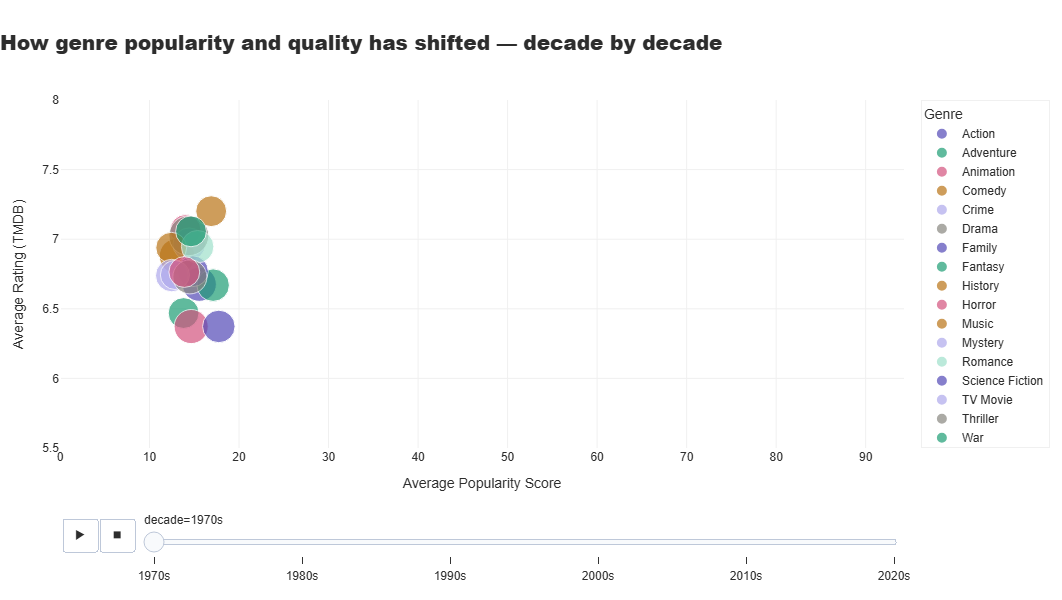

Chart 4 saved.


In [38]:
# Genre trends by decade
genre_decade = df_genres.groupby(['decade', 'genre']).agg(
    movie_count   = ('title', 'count'),
    avg_rating    = ('vote_average', 'mean'),
    avg_popularity= ('popularity', 'mean'),
    avg_roi       = ('roi', 'mean')
).reset_index()

# Keep only genres with enough data per decade
genre_decade = genre_decade[genre_decade['movie_count'] >= 10].copy()

# Colour map
genre_color_map = {
    'Action'         : '#534AB7',
    'Adventure'      : '#1D9E75',
    'Animation'      : '#D4537E',
    'Comedy'         : '#BA7517',
    'Crime'          : '#AFA9EC',
    'Documentary'    : '#9FE1CB',
    'Drama'          : '#888780',
    'Family'         : '#534AB7',
    'Fantasy'        : '#1D9E75',
    'Horror'         : '#D4537E',
    'Music'          : '#BA7517',
    'Mystery'        : '#AFA9EC',
    'Romance'        : '#9FE1CB',
    'Science Fiction': '#534AB7',
    'Thriller'       : '#888780',
    'War'            : '#1D9E75',
    'Western'        : '#D4537E',
    'History'        : '#BA7517',
    'TV Movie'       : '#AFA9EC'
}

genre_decade['color'] = genre_decade['genre'].map(
    genre_color_map).fillna('#888780')

# Normalise bubble size per decade
max_count = genre_decade['movie_count'].max()
genre_decade['bubble_size'] = (
    genre_decade['movie_count'] / max_count * 60 + 8).round(0)

fig = px.scatter(
    genre_decade,
    x='avg_popularity',
    y='avg_rating',
    animation_frame='decade',
    animation_group='genre',
    size='bubble_size',
    color='genre',
    color_discrete_map=genre_color_map,
    hover_name='genre',
    hover_data={
        'movie_count': True,
        'avg_rating': ':.2f',
        'avg_popularity': ':.2f',
        'bubble_size': False,
        'decade': False
    },
    size_max=60,
    range_x=[0, genre_decade['avg_popularity'].max() * 1.1],
    range_y=[5.5, 8.0],
    labels={
        'avg_popularity': 'Average Popularity Score',
        'avg_rating'    : 'Average Rating (TMDB)',
        'movie_count'   : 'Number of Movies'
    }
)

fig.update_layout(
    title=dict(
        text='How genre popularity and quality has shifted — decade by decade',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=600,
    margin=dict(l=60, r=40, t=100, b=80),
    font=dict(family='Arial', color='#2d2d2d'),
    legend=dict(
        title='Genre',
        bordercolor='#f0f0f0',
        borderwidth=1
    )
)

fig.update_xaxes(gridcolor='#f0f0f0')
fig.update_yaxes(gridcolor='#f0f0f0')

fig.write_html('charts/chart4_genre_trends_animated.html')
fig.write_image('charts/chart4_genre_trends_animated.png',
                width=1200, height=600, scale=2)

fig.show()
print("Chart 4 saved.")

## How Genre Popularity and Quality Has Shifted — Decade by Decade

Press play. Watch what happens.

The 1970s and 1980s are quiet — fewer movies, tighter clusters, lower popularity scores across the board. This isn't because those decades made worse films. It's because TMDB popularity is partially driven by current engagement, and a 1970s Drama competes for attention differently than a 2020s Action franchise. The data captures not just what was made, but what people are still watching and talking about.

The shift that matters most happens between the 1990s and 2000s. Action and Adventure start moving right — popularity climbing sharply — while ratings hold steady or drift slightly downward. The blockbuster era isn't just a cultural observation. It's visible in the data as a deliberate trade: audiences are getting more spectacle and slightly less substance, and they keep showing up anyway.

Animation is the genre that holds its position most consistently across every decade — high ratings, growing popularity, never dipping into the lower quadrants. It turns out the formula for Animation has been the same since the 1980s: make something that works for children and doesn't insult the adults who brought them. Pixar didn't invent that strategy. They just executed it better than anyone else.

Median rating by decade:
        median  mean  std  count
decade                          
1970s     6.90  6.83 0.69    760
1980s     6.55  6.54 0.76   1332
1990s     6.48  6.46 0.81   1993
2000s     6.40  6.36 0.84   3767
2010s     6.41  6.39 0.85   6926
2020s     6.70  6.69 0.78   1984


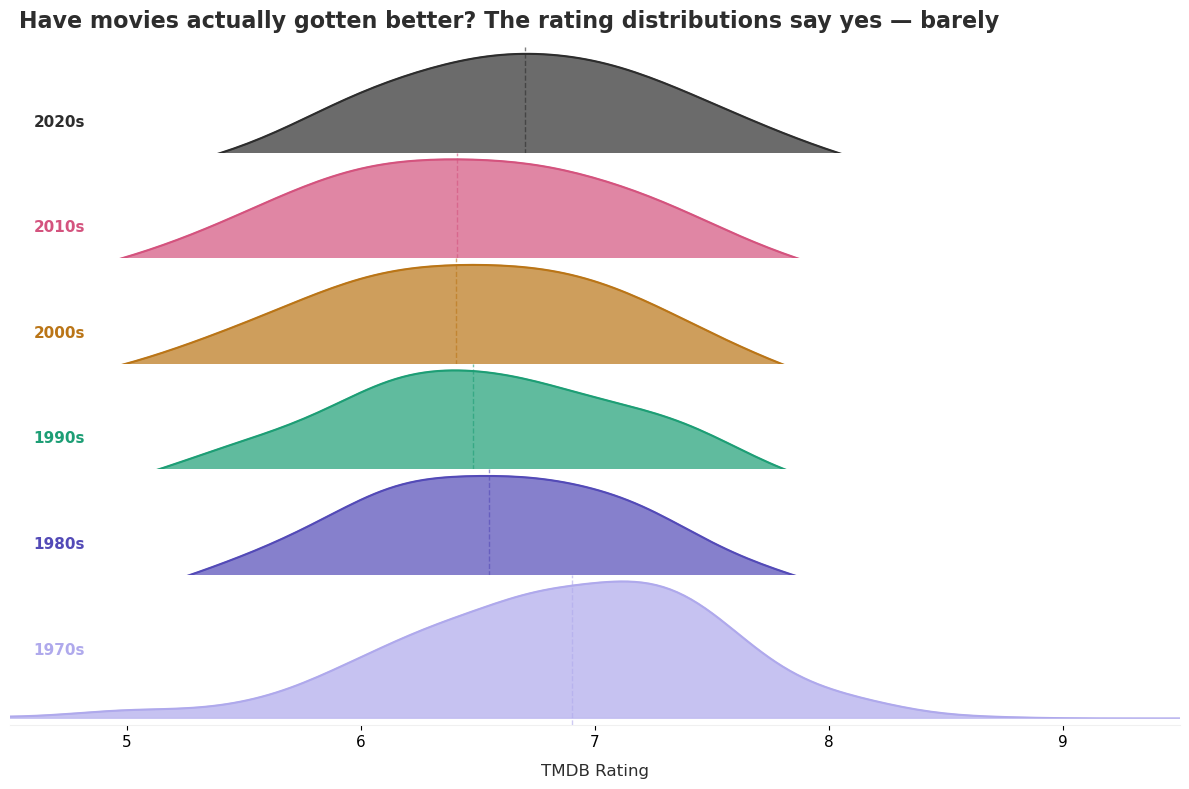

Chart 5 saved.


In [39]:
print("Median rating by decade:")
print(df_ridge.groupby('decade')['vote_average'].agg(
    ['median', 'mean', 'std', 'count']).round(2))

from matplotlib import cm
import matplotlib.patheffects as pe

# Decades to plot
decade_order = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
decade_colors = {
    '1970s': '#AFA9EC',
    '1980s': '#534AB7',
    '1990s': '#1D9E75',
    '2000s': '#BA7517',
    '2010s': '#D4537E',
    '2020s': '#2d2d2d'
}

# Filter to decades with enough data
df_ridge = df_clean[df_clean['decade'].isin(decade_order)].copy()

fig, axes = plt.subplots(
    len(decade_order), 1,
    figsize=(12, 8),
    sharex=True
)

fig.patch.set_facecolor('white')

overlap = 4.0

for i, decade in enumerate(reversed(decade_order)):
    ax = axes[i]
    data = df_ridge[df_ridge['decade'] == decade]['vote_average']
    color = decade_colors[decade]

    # KDE plot
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data, bw_method=0.3)
    x_range = np.linspace(1, 10, 300)
    y_kde = kde(x_range)

    # Scale for overlap effect
    y_scaled = y_kde * overlap

    ax.fill_between(x_range, y_scaled, alpha=0.7,
                    color=color, zorder=2)
    ax.plot(x_range, y_scaled, color=color,
            linewidth=1.5, zorder=3)
    ax.axhline(0, color='white', linewidth=1, zorder=4)

    # Decade label
    ax.text(0.02, 0.5, decade,
            transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color=color, va='center')

    # Clean up
    ax.set_facecolor('white')
    ax.set_yticks([])
    ax.set_xlim(4.5, 9.5)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Median line
    median_val = data.median()
    ax.axvline(median_val, color=color, linewidth=1,
               linestyle='--', alpha=0.6, zorder=5)

# X axis on bottom only
axes[-1].set_xlabel('TMDB Rating', fontsize=12,
                     color='#2d2d2d', labelpad=10)
axes[-1].tick_params(axis='x', labelsize=11)
axes[-1].spines['bottom'].set_visible(True)
axes[-1].spines['bottom'].set_color('#f0f0f0')

# Title
fig.suptitle(
    'Have movies actually gotten better? The rating distributions say yes — barely',
    fontsize=16, fontweight='bold', color='#2d2d2d',
    x=0.02, ha='left', y=0.98
)

plt.tight_layout()
plt.subplots_adjust(hspace=-0.3)

plt.savefig('charts/chart5_rating_ridge.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Chart 5 saved.")

## Have Movies Actually Gotten Better? The Rating Distributions Say Yes — Barely

This is the question every binge watcher argues about at some point. Usually around season three of something that started brilliantly and then didn't.

The 1970s distribution is the widest and sits furthest right — but don't read too much into it. Only 760 films from that decade have enough votes to appear in this dataset. These are the survivors: the films that people are still watching, still rating, still recommending fifty years later. Survivor bias makes every decade look better in retrospect. The 1970s just had more time to filter out the forgettable ones.

The 2000s and 2010s tell the real story. As content volume exploded — streaming wars, franchise factories, sequel machines — the rating distributions shifted slightly left and widened. More movies, more mediocrity, more of everything. The median dropped from 6.90 in the 1970s to 6.40 in the 2000s. That's not a collapse in quality. It's the mathematical consequence of making significantly more things and hoping some of them are good.

The 2020s are quietly interesting. The distribution is tightening and moving right again — median back up to 6.70. Whether that's the streaming platforms finally figuring out quality over quantity, or just the fact that bad 2020s films haven't had enough time to accumulate their deserved low ratings, is a question the data can't fully answer yet. Check back in 2035.

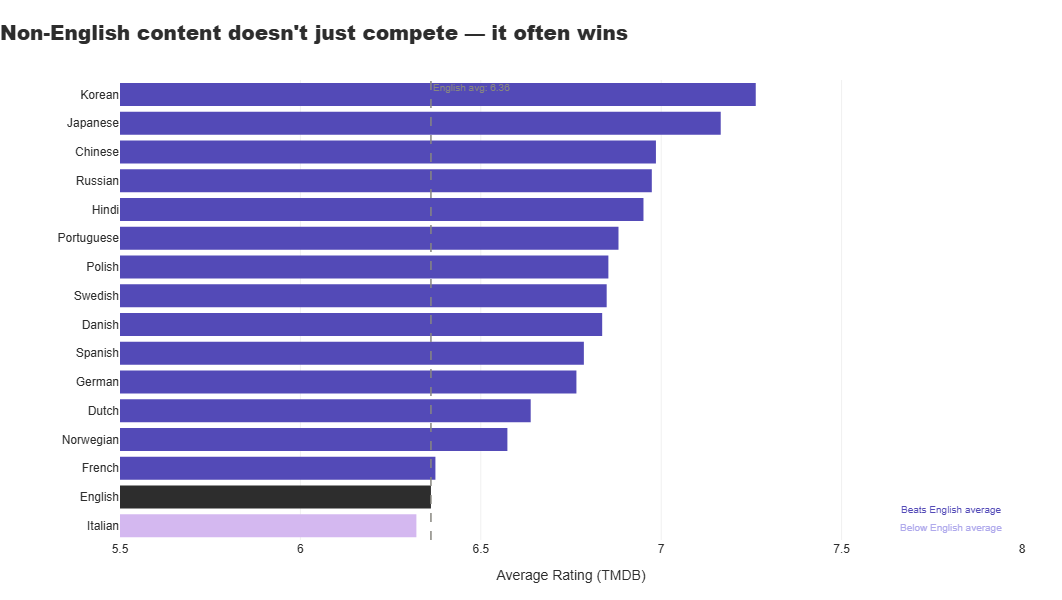

Chart 6 saved.


In [40]:
# Language analysis — minimum 50 movies for credibility
lang_analysis = df_clean.groupby('original_language').agg(
    movie_count  = ('title', 'count'),
    avg_rating   = ('vote_average', 'mean'),
    median_rating= ('vote_average', 'median'),
    avg_roi      = ('roi', 'mean'),
    median_roi   = ('roi', 'median'),
    avg_popularity=('popularity', 'mean')
).reset_index()

lang_analysis = lang_analysis[
    lang_analysis['movie_count'] >= 50].copy()

# Language name map
lang_names = {
    'en': 'English', 'fr': 'French', 'es': 'Spanish',
    'de': 'German', 'ja': 'Japanese', 'ko': 'Korean',
    'zh': 'Chinese', 'it': 'Italian', 'pt': 'Portuguese',
    'hi': 'Hindi', 'ru': 'Russian', 'tr': 'Turkish',
    'da': 'Danish', 'sv': 'Swedish', 'nl': 'Dutch',
    'pl': 'Polish', 'no': 'Norwegian', 'th': 'Thai',
    'fa': 'Persian', 'ar': 'Arabic',
    'cn': 'Cantonese'
}

lang_analysis['language_name'] = lang_analysis[
    'original_language'].map(lang_names).fillna(
    lang_analysis['original_language'])

# Drop duplicates — keep zh for Chinese, drop cn
lang_analysis = lang_analysis[
    lang_analysis['original_language'] != 'cn'].copy()

# English baseline
english_rating = lang_analysis[
    lang_analysis['original_language'] == 'en']['avg_rating'].values[0]

# Sort by avg rating descending
lang_analysis = lang_analysis.sort_values(
    'avg_rating', ascending=True)

# Colour — highlight non-English that beat English
lang_analysis['beats_english'] = (
    lang_analysis['avg_rating'] > english_rating) & \
    (lang_analysis['original_language'] != 'en')

lang_analysis['color'] = lang_analysis.apply(
    lambda x: '#534AB7' if x['beats_english']
    else ('#2d2d2d' if x['original_language'] == 'en'
    else '#D4B8F0'), axis=1
)

fig = go.Figure()

# Bars
fig.add_trace(go.Bar(
    x=lang_analysis['avg_rating'],
    y=lang_analysis['language_name'],
    orientation='h',
    marker=dict(
        color=lang_analysis['color'],
        line=dict(width=0)
    ),
    customdata=lang_analysis[[
        'movie_count', 'avg_rating',
        'median_roi', 'original_language']].values,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Avg Rating: %{customdata[1]:.2f}<br>"
        "Median ROI: %{customdata[2]:,.0f}%<br>"
        "Movies: %{customdata[0]:,}<extra></extra>"
    )
))

# English baseline reference line
fig.add_vline(
    x=english_rating,
    line_dash='dash',
    line_color='#888780',
    line_width=1.5,
    annotation_text=f'English avg: {english_rating:.2f}',
    annotation_position='top right',
    annotation_font=dict(size=10, color='#888780')
)

# Clean legend annotations
fig.add_annotation(
    x=0.98, y=0.05,
    xref='paper', yref='paper',
    text='Beats English average',
    showarrow=False,
   font=dict(size=10, color='#534AB7'),
    xanchor='right'
)

fig.add_annotation(
    x=0.98, y=0.01,
    xref='paper', yref='paper',
    text='Below English average',
    showarrow=False,
    font=dict(size=10, color='#AFA9EC'),
    xanchor='right'
)

fig.update_layout(
    title=dict(
        text="Non-English content doesn't just compete — it often wins",
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0, pad=dict(b=20)
    ),
    xaxis=dict(
        title='Average Rating (TMDB)',
        gridcolor='#f0f0f0',
        range=[5.5, 8.0]
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=600,
    margin=dict(l=120, r=40, t=80, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    showlegend=False
)

fig.write_html('charts/chart6_language_analysis.html')
fig.write_image('charts/chart6_language_analysis.png',
                width=1200, height=600, scale=2)

fig.show()
print("Chart 6 saved.")

## Non-English Content Doesn't Just Compete — It Often Wins

Let's talk about Korean drama for a second. Because if you've ever started one "just to see what the fuss is about" and then found yourself at 3am genuinely emotional about two people who haven't even held hands yet — you already understand why this chart looks the way it does. Korean storytelling has a particular talent for making you feel things you didn't consent to feeling. Slowly. Beautifully. With an absolutely devastating OST playing in the background.

But the romantic pull of K-drama isn't just a cultural moment. It's a data point. Korean content sits at the top of this chart by a meaningful margin — nearly half a rating point above English language content. Japanese, Chinese, Russian and Hindi content all outperform English too. This isn't a rounding error. In a world where the difference between a 6.5 and a 7.0 is the difference between word-of-mouth and obscurity, half a point is a storyline arc.

Netflix spent billions localising its platform, commissioning Korean dramas, backing Spanish thrillers, funding French cinema. The conventional wisdom was that this was a growth strategy — reach new markets, add subscribers. The data suggests it was also a quality strategy, whether they knew it or not. Non-English productions typically work with smaller budgets, tighter creative control, and less interference from the franchise-obsessed logic that dominates Hollywood. They make things because they have a story to tell. Turns out the audience — the one binge watching at 3am with subtitles on — can tell the difference.

English isn't losing. But it's no longer automatically winning either. And somewhere in Seoul, a writer's room is already working on the show that will make you cancel your weekend plans without any warning whatsoever.

---

## So, Does The Streaming Formula Actually Exist?

Let's set the scene. It's 11pm. You told yourself one episode. You are now four episodes in, you have work tomorrow, and you are genuinely invested in whether two people who have exchanged approximately twelve words are going to end up together. Somewhere in a boardroom, someone made a spreadsheet that led to this moment. This project was an attempt to find that spreadsheet.

After 900,000 movie entries, 16,762 meaningful ones, six analyses, and one rabbit hole that started with "I wonder if Documentary has good ROI" and ended with strong opinions about Korean release strategies — here's what the data actually says.

There isn't one formula. There are several. And the platforms that are winning right now are the ones that have figured out which formula applies to which decision. Buckle up.

---

### The Five Things The Data Actually Proved

**1. Genre is a business model, not just a category.** Documentary has the highest ROI and the highest ratings simultaneously — the only genre sitting in the top right quadrant. Horror has terrible ratings and genuinely decent ROI. Drama has the most volume and the most middling returns. These aren't accidents. They're the consequence of decades of deliberate decisions about what to make, how much to spend, and who to make it for. A streaming platform commissioning content without understanding its genre's position on the profitability matrix is essentially throwing very expensive darts in the dark and hoping the algorithm catches them.

**2. The release calendar is a confession.** January is where studios send the films they don't believe in, because they know audiences are captive and have nowhere else to go. June is where they send the ones they want to be loud and profitable. December — and this is the genuinely interesting one — is the only month where commercial ambition and actual quality align simultaneously. Highest revenue AND highest ratings of any month in the dataset. If you want to know how much a studio believes in a film, don't read the press release. Check the release date. The calendar never lies.

**3. Bigger budgets buy bigger audiences — not better movies.** The trend line between budget and rating is essentially flat. Spend $120,000 or spend $460,000,000 — the average rating you'll get back is roughly the same. And the trend line between budget and ROI? It slopes downward. The highest returns in this dataset come from low and mid budget films made with constraint, intention, and a story that didn't need $80 million in visual effects to work. The blockbuster model functions when it functions. The data says it functions less reliably than the marketing budgets suggest. Considerably less.

**4. The 2000s and 2010s were the worst decades for movie quality — and the 2020s are quietly fixing it.** As content volume exploded, rating distributions shifted left. More movies, more mediocrity, more of absolutely everything. The 2020s median is creeping back up to levels not seen since the 1970s and 1980s. Whether that's the streaming quality wars finally producing results, or simply the fact that bad 2020s films haven't had enough time to accumulate their fully deserved low ratings, is a question worth revisiting around 2030. Set a calendar reminder.

**5. Non-English content isn't a diversity initiative — it's a competitive advantage.** Korean content outperforms English by nearly half a rating point. Japanese, Chinese, Hindi and Russian content all beat the English average too. Netflix didn't just open new markets when it went global. It accidentally discovered that the best storytelling wasn't exclusively coming from Hollywood. The audience — the one watching with subtitles on at 3am, genuinely emotional about a slow burn romance involving approximately zero physical contact and one umbrella scene — already knew this. The data just confirmed it.

---

### What A Streaming Platform Should Do With This

**Content acquisition teams** should be tracking genre ROI quartiles, not just critical reception scores. Documentary and Horror sit at opposite ends of the rating spectrum and both consistently return on investment. That's two very different creative bets worth making simultaneously — and the data says both pay off.

**Release strategy teams** should be treating December like the premium real estate it demonstrably is, and January like the liability it's proven to be every single year without exception. The data doesn't forgive January. Neither do audiences.

**International content teams** should be using rating performance by language as a commissioning signal, not just a market access strategy. Korean, Japanese and Chinese content consistently outperforms English on quality metrics. Commissioning more of it isn't cultural goodwill. It's data-driven programming dressed up as open-mindedness.

**Finance teams** should be deeply, structurally sceptical of any pitch that justifies a $200M+ budget primarily on the basis that bigger equals better. The scatter plot disagrees. Loudly. With 6,464 data points behind it.

---

### What The Data Couldn't Tell Us

This dataset has no streaming-specific viewing figures — no watch hours, no completion rates, no subscriber impact data. Revenue here means box office receipts, not streaming royalties. The formula for what makes a film successful in a cinema is related to but not identical to what makes a series compulsively unwatchable-to-stop at midnight. That analysis requires data that streaming platforms guard more carefully than their recommendation algorithms and considerably more carefully than their password sharing policies.

What we have is the foundation. The genre dynamics, the budget relationships, the language quality gap, the release window patterns — these are the structural forces that shaped the streaming era before anyone had a login to share. They haven't stopped mattering just because the distribution model changed and everything is now technically available on four different platforms simultaneously if you know which ones your family members subscribe to.

The formula exists. It's just not one formula. It's the intersection of genre discipline, release timing, budget restraint, and the willingness to bet on stories that don't need to be in English, don't need a $200 million budget, and don't need to be released in June to be worth watching.

Some of them just need to be good. Turns out that's still enough.

---

*Built with Python, pandas, Plotly, Seaborn, and a completely unreasonable number of hours that could have been spent actually watching something instead of analysing why things get watched.*

*Data: TMDB Movies Dataset 2024 via Kaggle · Analysis: Trupthi Raj*

---

📁 **GitHub:** [github.com/trupthiraj](https://github.com/trupthiraj)
📊 **Tableau Public:** [public.tableau.com/app/profile/trupthi.raj](https://public.tableau.com/app/profile/trupthi.raj/vizzes)